### SVM 
- 简介
- 推导过程
- 非线性划分
- sklearn应用

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
import pandas as pd
from sklearn.inspection import DecisionBoundaryDisplay
import sklearn.datasets  as sk_datasets

### 简介
支持向量机是一种监督学习算法，应用于分类和回归认为，它的核心思想是在特征空间中找到一个最优划分的超平面，使两类数据到超平面的距离最大化。形象地说，SVM就像是在两类数据点之间铺设一条尽可能宽的“街道”，将两边隔开。最终决定这条街道宽度和位置的，并不是大部分普通样本，而是那些刚好落在街道边缘（或违规侵入街道内部）的关键样本，它们被称为支持向量。

在实际数据中，没有完全重叠与噪声的线性可分场景极少，为此 SVM 引入了两大扩展：
- 软间隔：允许部分样本侵入间隔甚至被误分类，通过惩罚参数 $C$ 调节“街道宽度”与“违规惩罚”的平衡，防止模型因少数异常点而过拟合。
> 超参数惩罚参数 $C$：平衡“街道宽度”与“违规容忍度”。
> - $C$ 较小：街道更宽，容忍更多点落在间隔内，模型偏差略高但方差低（抗噪好，防过拟合）。
> - $C$ 较大：街道更窄，极少容忍违规点，容易过拟合。核函数参数（如 RBF 核中的 $\gamma$）：控制单个样本的影响范围。$\gamma$ 越大，高斯钟形曲线越窄，决策边界越复杂曲折。
- 核技巧：面对复杂的非线性数据，核函数无需显式映射高维坐标，便能巧妙计算样本在升维后的空间内积，从而在高维空间中轻松实现线性划分（映射回原空间即为弯曲的非线性决策边界）。
> 很多人误以为核技巧是“先把低维算成高维坐标，再在高维计算”。实际上核技巧的核心在于避免显式计算高维映射，而是通过核函数 $K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$ 直接在低维空间计算高维内积，极大降低了计算复杂度，避开了“维度灾难”。常见核函数可顺带列举：线性核（Linear）、多项式核（Polynomial）、高斯径向基核（RBF）。
注意由于SVM基于样本间距离计算间隔，对数据进行标准化缩放很重要

<details>
  <summary><b>支持向量机回归</b></summary>
  <p>SVC 分类：目的是在两类之间建立一条尽可能宽的街道，尽能的不让数据点落入节点内部<p/>
  <p>SVR 回归：目的建立一条宽度维2e的街道，去拟合所有数据点，尽量让所有数据点在街道内部</p>
  <br>
  <h5>核心机制</h5>
  <p>SVR 不像普通最小二乘线性回归那样去惩罚每一个预测误差，而是规定了一个“容忍带”,只要样本点落在这条宽度为 2e 的街道内部（预测误差 |y - f(x)| < e），误差直接视为 0，不计入损失。这赋予了SVR极强的抗噪能力</p>
  <h5>SVR 中的支持向量</h5>
  <p>决定支持向量的数据点为落在街道边缘或者掉在街道外部的样本点，那些街道里面的则被忽略，不会改变回归线</p>
  <h5>超参数</h5>
  <p>街道宽度 e:街道越宽容忍度越高，落入街道内的样本越多</p>
  <p>惩罚系数 C:控制对掉在街道外部点的惩罚力度，值越大对外界点惩罚越重，回归线会近可能贴近一场点</p>
  <h5>非线性问题</h5>
  <p>与SVC一样都是使用核技巧</p>
  <h5>总结</h5> 
  <p>如果说分类 SVM 是在两类样本之间铺设一条尽量排斥数据点的宽马路，那么回归任务中的 SVR则是铺设一条尽量把所有数据点包裹进来的街道。只要数据点落在街道内，模型就视而不见；只有落在街道边缘或外部的点，才会成为支持向量来决定整条回归线的走向。配合核函数，SVR 能够平滑且极具鲁棒性地拟合复杂的非线性曲线。</p>
</details>

In [ ]:
# todo 画图 解释泛化效果，提升维度

### 推导过程
#### 前置知识


**超平面（Hyperplane）**
超平面可以理解为高维空间里的“分界线”：一维空间是一个点，二维空间是一条线，三维空间是一个面。其数学方程为：
$$W^T X + b = 0$$
其中 $W$ 为法向量，$X$ 为样本向量，$b$ 为截距偏置。在二维平面中，$W = \begin{bmatrix}w_1\\w_2\end{bmatrix}, X = \begin{bmatrix}x_1\\x_2\end{bmatrix}$，内积展开即为 $w_1 x_1 + w_2 x_2 + b = 0$

**点到平面距离**

任意样本点 $X_i$ 到超平面的垂直距离为：
$$d = \frac{|W^T X_i + b|}{\|W\|}$$

[拉格朗日乘数](../Math/calculus/拉格朗日乘数.ipynb)

#### 拉格朗乘数转换
有了上面的前置公式现在开始推导SVM远离，前面说了它的核心思想是在特征空间里找到一个找到最优平面，使两类数据离平面尽能能远。给定数据集$(X_i,y_i)$，y是标签$y \in \{1,-1\}$。超平面需满足：
* 当 $y_i = +1$ 时，$W^T X_i + b > 0$
* 当 $y_i = -1$ 时，$W^T X_i + b < 0$

统一写作：$y_i(W^T X_i + b) > 0$。

SVM 的核心是**最大化两类数据之间的间隔（Margin）**。两类距离超平面最近的样本点被称为**支持向量**，这两类支持向量到超平面的几何距离各为 $d_{\min}$，整个分界带的宽度（街道全宽）即为：
$$\text{Margin} = 2 \cdot \frac{\min_i |W^T X_i + b|}{\|W\|}$$

利用超平面的尺度冗余性（方程两侧同乘任意非零常数，超平面保持不变），我们可以对 $W$ 和 $b$ 等比例缩放，使得离超平面最近的支持向量满足：
$$|W^T X_i + b| = 1$$

此时所有样本均满足 $y_i(W^T X_i + b) \ge 1$。街道宽度简化为 $\frac{2}{\|W\|}$。

最大化宽度 $\max \frac{2}{\|W\|}$，等价于最小化 $\frac{1}{2}\|W\|^2$（平方项消去了范数根号，便于求导）：

$$
\begin{cases}
\min_{W, b} \frac{1}{2} \|W\|^2 \\
\text{s.t.} \quad 1 - y_i(W^T X_i + b) \le 0, \quad i = 1, \dots, n
\end{cases}
$$

构造广义拉格朗日函数（引入乘子 $\lambda_i \ge 0$）：
$$L(W, b, \lambda) = \frac{1}{2} \|W\|^2 + \sum_{i=1}^n \lambda_i \Big(1 - y_i(W^T X_i + b)\Big)$$

分别对 $W$ 和 $b$ 求偏导并令其为 0：
$$
\begin{cases}
\frac{\partial L}{\partial W} = W - \sum_{i=1}^n \lambda_i y_i X_i = 0 \implies W = \sum_{i=1}^n \lambda_i y_i X_i \\
\frac{\partial L}{\partial b} = -\sum_{i=1}^n \lambda_i y_i = 0 \implies \sum_{i=1}^n \lambda_i y_i = 0
\end{cases}
$$



代入拉格朗日函数
<details>
  <summary><b>👉化简过程</b></summary>
  
 将上述解代回 $L(W, b, \lambda)$：
$$
\begin{aligned}
L(W, b, \lambda) &= \frac{1}{2} W^T W + \sum_{i=1}^n \lambda_i - \sum_{i=1}^n \lambda_i y_i W^T X_i - b \sum_{i=1}^n \lambda_i y_i \\
&= \frac{1}{2} W^T W + \sum_{i=1}^n \lambda_i - W^T \left(\sum_{i=1}^n \lambda_i y_i X_i\right) - b \cdot 0 \\
&= \frac{1}{2} W^T W + \sum_{i=1}^n \lambda_i - W^T W \\
&= \sum_{i=1}^n \lambda_i - \frac{1}{2} W^T W
\end{aligned}
$$

展开 $W^T W$ 内积：
$$W^T W = \sum_{i=1}^n \sum_{j=1}^n \lambda_i \lambda_j y_i y_j (X_i^T X_j)$$

最终得到对偶目标函数：
$$L(\lambda) = \sum_{i=1}^n \lambda_i - \frac{1}{2}\sum_{i=1}^n \sum_{j=1}^n \lambda_i \lambda_j y_i y_j (X_i^T X_j)$$
  
</details>



化简后 $L(\lambda)=\sum_{i=1}^n \lambda_i - \frac{\sum_{i}^n\sum_{i}^n\lambda_i \lambda_j y_i y_j (x_i \dot x_j)}{2}$

todo $L(\lambda)可以转换为二次型格拉姆矩阵$

<details>
  <summary><b>👉解出对偶问题的最优解

$$ 
\lambda^* = (\lambda_1^*, \lambda_2^*, \dots, \lambda_n^*) 
$$ 

之后，反推最终超平面方程 

$$ 
W^T X + b = 0 
$$ 
   
的完整步骤如下：</b></summary>

### 一、 求解法向量 $W^*$

在推导拉格朗日函数对 $W$ 求偏导时，已经得到了 $W$ 与 $\lambda$ 的显式关系：


$$W^* = \sum_{i=1}^n \lambda_i^* y_i X_i$$

根据 **KKT 互补松弛条件**（Complementary Slackness）：


$$\lambda_i^* \Big(1 - y_i(W^{*T} X_i + b^*)\Big) = 0$$

* 对于绝大多数不在街道边缘的样本点，有 $y_i(W^T X_i + b) > 1$，此时对应的乘子**必然为零**（$\lambda_i^* = 0$）。
* 只有刚好落在街道边缘的**支持向量（Support Vectors, 设集合为 $S$）**，乘子才严格大于零（$\lambda_i^* > 0$）。

因此，$W^*$ 最终仅由极少数支持向量线性组合决定，普通样本对求和没有任何贡献：


$$W^* = \sum_{i \in S} \lambda_i^* y_i X_i$$

---

### 二、 求解偏置截距 $b^*$

在对偶推导中，对 $b$ 求偏导的方程是 $\sum \lambda_i y_i = 0$，并不能直接解出 $b$。

$b^*$ 的求解同样依赖支持向量的临界性质。既然对任意支持向量 $X_s \in S$（满足 $\lambda_s^* > 0$），它都严格落在边缘上：


$$y_s (W^{*T} X_s + b^*) = 1$$

因为 $y_s \in \{-1, +1\}$（且 $y_s^2 = 1$），方程两边同乘以 $y_s$：


$$W^{*T} X_s + b^* = \frac{1}{y_s} = y_s \implies b^* = y_s - W^{*T} X_s$$

代入前面求出的 $W^*$：


$$b^* = y_s - \sum_{i \in S} \lambda_i^* y_i (X_i^T X_s)$$

> **工程技巧**：理论上挑选任意一个支持向量 $X_s$ 都能算出 $b^*$。但在实际数值计算中存在浮点误差，通常会对**所有支持向量算出的 $b$ 取算术平均值**，以增强数值稳定性：
> 
> $$b^* = \frac{1}{\vert{}S\vert{}} \sum_{s \in S} \left( y_s - \sum_{i \in S} \lambda_i^* y_i (X_i^T X_s) \right)$$
> 
> 

---

### 三、 最终分类决策函数

求出 $W^*$ 与 $b^*$ 后，得到最终的最优超平面方程：


$$\left( \sum_{i \in S} \lambda_i^* y_i X_i \right)^T X + b^* = 0$$

当输入一个新的待预测样本 $X_{\text{new}}$ 时，将其代入超平面符号函数进行分类：


$$f(X_{\text{new}}) = \text{sign}\left( W^{*T} X_{\text{new}} + b^* \right) = \text{sign}\left( \sum_{i \in S} \lambda_i^* y_i (X_i^T X_{\text{new}}) + b^* \right)$$

若引入**核函数 $K(X_i, X_j)$**，直接将样本内积 $X_i^T X_{\text{new}}$ 替换即可：


$$f(X_{\text{new}}) = \text{sign}\left( \sum_{i \in S} \lambda_i^* y_i K(X_i, X_{\text{new}}) + b^* \right)$$

<details>
---- 

为什么能转成“先求极小，再求极大”的对偶问题
原问题是在满足约束 $g_i(w,b) \le 0$ 的前提下求目标函数 $f(w) = \frac{1}{2}\Vert{}w\Vert{}^2$ 的最小值。我们构造了拉格朗日函数： $L(w,b,\lambda)=f(w,b)+\lambda g(w,b)$
1. 确定L是原问题的下界
$$\begin{cases}
\lambda >=0  \\
g(x) <=0 
\end{cases} 
$$
$$
\lambda g(x) <= 0 
$$ 
所以 $L(w,b,\lambda)<=f(w,b)$。最关键点也在于这个不等式，从它开始转换视角。$L(w,b,\lambda)$ 是关于 $f(w,b)$ 的下界最小值

2. 构建对偶函数 $q(\lambda)$
既然对任意可行的 $(w,b)$，拉格朗日函数都小于等于 $f(w)$，那么固定 $\lambda$ 时，$L(w, b, \lambda)$ 对所有 $(w,b)$ 取得的最小值（记为对偶函数 $q(\lambda) = \min_{w,b} L$），也必然是原问题最优值 $p^*$ 的一个更紧的下界：

3. 逼近最优解
为了让这个下界尽可能逼近真实的最小值 $p^*$，我们自然要在所有合法的 $\lambda \ge 0$ 中寻找它的最大值，即：$\max_{\lambda \ge 0} q(\lambda) = \max_{\lambda \ge 0} \min_{w,b} L(w, b, \lambda)$
又因为 SVM 的目标函数是严格凸函数，此时强对偶性成立，最大化的下界与原问题的最小值完全重合（$\max q = \min f$）。这就是我们将极小值问题转换为对偶问题求解的数学本质。











### 非线性划分
软间隔
> todo 暂时没理解 这个两个变量对于的图
核心超平面间隙内能够容量数据点，这时引入两个重要参数
- 松弛变量 $\xi$
- 惩罚因子 C

对之前的约束条件进行改造
$$y_i(W^T X_i + b) >= 1 - \xi$$

数据点到边界距离
$$d=\frac{\xi}{||w||}$$

优化问题
$$
arg min_{w,b,\xi}=\frac{w \dot w}{2} + C \sum_{i=1}^n \xi_{i}
$$
满足 $$\begin{cases} 
   y_i(W^T X_i + b) >= 1 - \xi\\
   \xi_{i}>=0 
 \end{cases} $$


核技巧

核心将数据映射到高维度的特征空间中，使数据在高维空间里变得线性可分



怎么构建高维度特征空间
原始数据$(x_1,x_2)$，我们自己规定一个特征变化 $\phi(x_1,x_2)$，例如$\phi(x_1,x_2)=(x_1^2,x_1x_2,x_2^2$于是原来的二维点变成三维度点$(z_1,z_2,z_3)=(x_1^2,x_1x_2,x_2^2)。然后在这个新的特征空间训练数据，得到这个空间的超平面$w_1z_1+w_2z_2,w_3z_3+b$



先用二维数据举个举例
假设数据点分布一个在椭圆内一个在椭圆外，超平面为一条直线$w_1x_1+w_2x_2+b=0$，这时就不满足我们要求。所以现在要做就是把二维数据升高到三维，通过原有的特征数据组合新的高维度特征数据，比如$\phi(x_1,x_2)->(x_1^2,x_1x_2,x_2^2)$，在高维空间的超平面变成$w_1x_1^2+w_3x_2^2+w_2x_1x_2+b=0$，在通过前面的拉格朗日函数计算出对应W，我们假设w1=1/4，w2=0，w3=1，b=0便可得到椭圆方程$\frac{x_1^2}{4}+x_2^2=0$

<div class="alert alert-info" style="border-radius: 5px;">
  <b>📘 流程步骤整理 </b>

1. 在原有的特征数据组合新的特征数据
$$z=\phi(x)$$
2. 高维度特征空间平面
$$W^Tz+b=0$$
3. 联合起来
$$
W^T\phi(x)+b=0
$$
$$
\phi(x)=\begin{bmatrix}x_1^2 \\ x_1x_2 \\ x_2^2 \end{bmatrix} 
$$
于是
$$
W^T\phi(x)=w_1x_1^2+w_3x_2^2+w_2x_1x_2+b
$$
让它放回二维平面（高维中的平面，经过特征映射的逆向解释，在原始二维空间中表现成一个椭圆。）
$$
0=w_1x_1^2+w_3x_2^2+w_2x_1x_2+b
$$
</div>

核函数

经过上面的推导最后的决策函数$W^TX+b$的最终形态为

$$
f(x)=\sum_{i}\lambda_i y_i x_i^Tx+b (x_i训练数据，x新数据)
$$ 

可以看到SVM使用了$ x_i^Tx$两个数据的内积，这里对原有数据进行生维$x->\phi(x)$，那么$ x_i^Tx$变成$\phi(x)^T\phi(x)$也就是高维空间中两个样本的内积。

这里就可以定义核函数
$K(x_i,x)=\phi(x_i)^T\phi(x)$，它干的事情特别简单，输入原始数据$x_i$，新数据x，直接计算出生维以后在高维度空间的内积。

假设$x=(x_1,x_2)$ 做二次映射原始数据$\phi(x)=(x_1^2,\sqrt{2}x_1x_2,x_2^2)$，新数据$\phi(z)=(z_1^2,\sqrt{2}z_1z_2,z_2^2)$那么K(x,z)=$x_1^2z_1^2+2x_1x_2z_1z_2+x_2^2z_2^2=(x_1z_1+x_2z_2)^2$ ，K(x,z)=$(x^Tz)^2$得到一个二次多项式核
可以看到有了核函数，不用让x特征转换后在内积，而直接用$(x^Tz)^2$计算得到效果一样
> 如果原始数据有 $1000$ 个特征，想看所有特征两两相乘的二阶组合：
- 升维后的向量 $\phi(x)$ 长度约为 $\frac{1000 \times 1000}{2} \approx 500{,}000$ 维。
- 如果真的算 $\phi(x)$：每个样本要先算出 50 万个坐标存进内存，每算一次内积要执行 50 万次乘法加法。
- 用核函数 $K(x, z) = (x^T z + 1)^2$：只算 1000 维的原始点积，加 1，再平方一次，总计算量大约千次操作。耗时和内存相差几百倍。

> 默瑟定理的核心结论(核函数与特征转换成立)：任何一个对称函数 $K(x, z)$，如果它对任意数据集算出来的核矩阵（Kernel Matrix / Gram 矩阵）都是半正定的（Positive Semi-Definite），那么数学上必然存在某个希尔伯特空间（高维甚至无穷维空间）以及对应的映射 $\phi$，使得：$$K(x, z) = \langle \phi(x), \phi(z) \rangle$$

多项式核
根据上面阐述在来看多项式就是每个特征两两相乘，三三相乘组合的复合特征
$K(x,z)=(x^Tz)^n$

高斯核

$K(x,z)=exp(-\frac{||x-z||^2}{2 \sigma^2})$
它应对的特征空间不是有限维的，而是可以看成一个无维度特征空间

<details>
  <summary><b>👉 点击展开：高斯核到无限特征空间</b></summary>
展开
$$ \|x-z\|^2 = \|x\|^2+\|z\|^2-2x^Tz $$

所以：

$$ K(x,z) = \exp\left( -\frac{\|x\|^2}{2\sigma^2} \right) \exp\left( -\frac{\|z\|^2}{2\sigma^2} \right) \exp\left( \frac{x^Tz}{\sigma^2} \right) $$

现在注意最后这个：

$$ e^{x^Tz/\sigma^2} $$

我们知道：

$$ e^t = 1+t+\frac{t^2}{2!} +\frac{t^3}{3!} +\cdots $$

所以：

$$ e^{x^Tz/\sigma^2} = 1+ \frac{x^Tz}{\sigma^2} + \frac{(x^Tz)^2}{2!\sigma^4} + \frac{(x^Tz)^3}{3!\sigma^6} +\cdots $$

你现在应该突然看到一个熟悉的东西：

$$ (x^Tz) $$ $$ (x^Tz)^2 $$ $$ (x^Tz)^3 $$

……

这些分别对应：

一次特征、二次特征、三次特征……

所以高斯核可以粗略理解成：

​$$ 
\phi(x)= 
\begin{bmatrix}​1 \\
x_1 \\
x_2\\
x_1^2\\
x_1x_2\\
x_2^2\\
x_1^3\\
x_1^2x_2\\
​x_1x2^2\\
x_2^3 \\
... \\
\end{bmatrix}
​$$
	​

	
注意这里省略了很多系数。

这就是：

$$ (x_1,x_2) \rightarrow \text{无穷多种多项式特征} $$

所以高斯核不是简单地：

$$ 2维\rightarrow3维 $$

也不是：

$$ 2维\rightarrow10维 $$

而是可以理解成：

$$ 2维\rightarrow \infty维 $$
	​
</details>
多项式核是在“明确地增加多项式特征”；高斯核则相当于同时增加无限多阶的特征。核函数的厉害之处在于，我们不用真的把这些新坐标构造出来，只计算它们之间的内积就够了。




> 我这里之前一直卡的一个地方,我先从结果看到数据点复合椭圆，然后想着构造特征空间直接用构造出$(x_1,x_2,x_1^2/a^2+x_2^2/b^2)$这样的空间进行预测，然后用高度分布（等高线）进行划分。这相当于作弊。SVM通过构造新的特征空间，在这个新的特征空间里找到最优的超平面，这个超平面逆向解析原有空间就成了曲线。也就是上面一开说的一句话，通过提升维度到新的特征空间，找到超平面使数据变得线性可分

In [ ]:
iris=sk_datasets.load_iris()
data=iris['data']
feature_names=iris['feature_names']
target_names=iris['target_names']
target=iris['target']

data=np.column_stack([data,target])


feature_names=np.char.replace(feature_names,'(cm)','')
feature_names=np.char.rstrip(feature_names,' ')
feature_names=np.char.replace(feature_names,' ','_')
df=pd.DataFrame(data=data,columns=[*feature_names,'target'])
df=df.convert_dtypes()
df

In [49]:
data=df.loc[df['target'].isin([0,1])].loc[:,['sepal_length','sepal_width','target']]

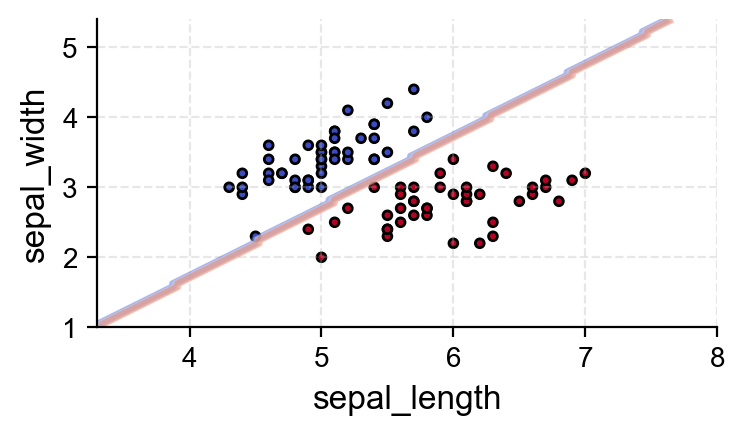

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline,make_pipeline

Train,Test=train_test_split(data,test_size=0.1)

TestX,TestY=Test[['sepal_length','sepal_width']],Test['target']
TrainX,TrainY=Train[['sepal_length','sepal_width']],Train['target']
linear=svm.LinearSVC(C=1)
pipe=Pipeline([('scaler',StandardScaler()),('fit',linear)])


model=pipe.fit(TrainX,TrainY)
fig, ax = plt.subplots(figsize=(4, 2))
DecisionBoundaryDisplay.from_estimator(
    model, 
    TrainX,  
    ax=ax,   
    response_method="predict",
    plot_method="contour",
    alpha=0.3,
    cmap='coolwarm'
)
scatter = ax.scatter(TrainX['sepal_length'], TrainX['sepal_width'], 
                     c=TrainY, edgecolors='k', cmap='coolwarm', s=10)

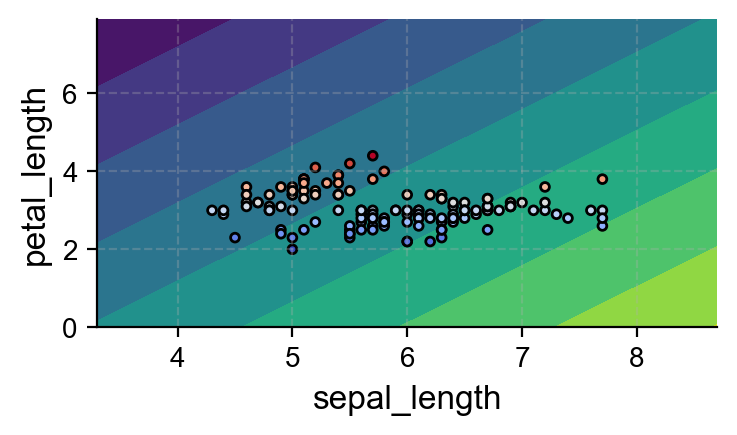

In [ ]:
Train,Test=train_test_split(df,test_size=0.1)


TrainX,TrainY=Train[['sepal_length','petal_length']],Train['sepal_width']
TestX,TestY=Test[['sepal_length','petal_length']],Test['sepal_width']
linear_r=svm.LinearSVR(max_iter=10000)
pipe=Pipeline([('scaler',StandardScaler()),('SVR',linear_r)])
model=pipe.fit(TrainX,TrainY)
fig, ax = plt.subplots(figsize=(4, 2))
DecisionBoundaryDisplay.from_estimator(pipe,X=TrainX,ax=ax,response_method='predict')
scatter = ax.scatter(Train['sepal_length'], Train['sepal_width'], 
                     c=TrainY, edgecolors='k', cmap='coolwarm', s=10)


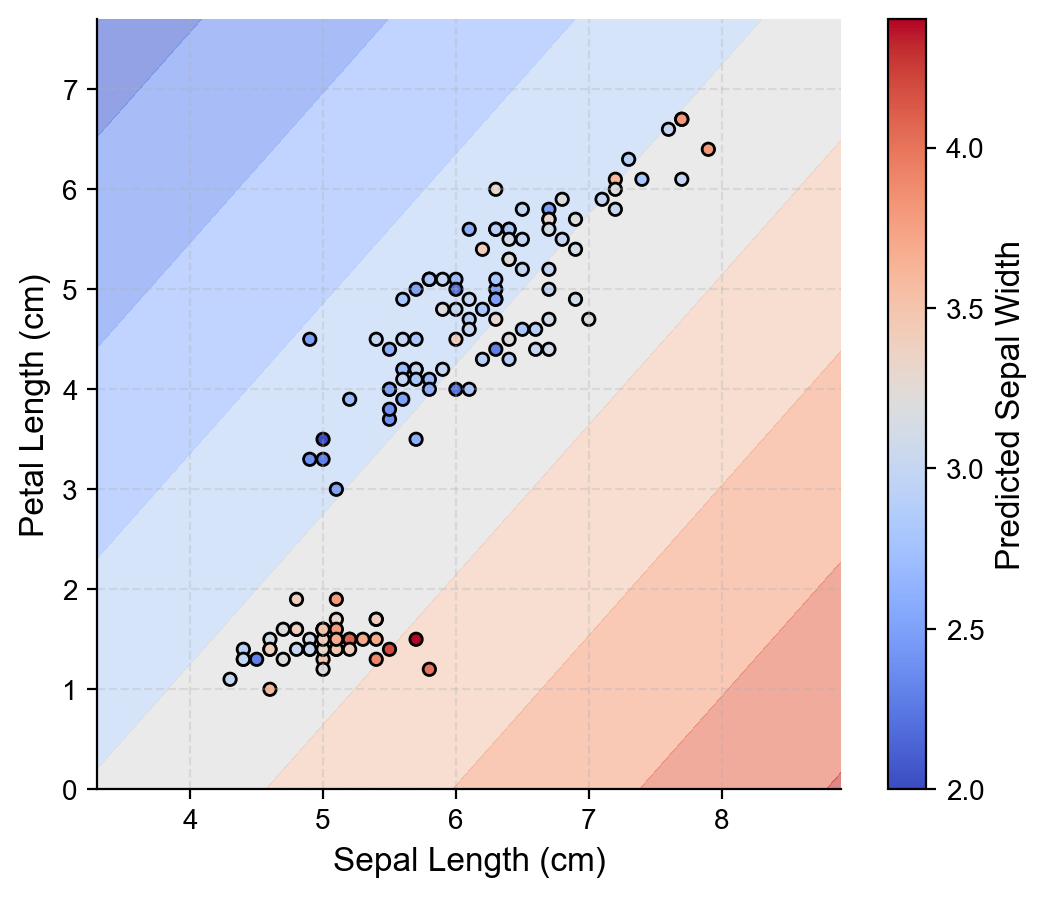

In [ ]:
Train, Test = train_test_split(df, test_size=0.1, random_state=42)

TrainX = Train[['sepal_length', 'petal_length']]
TrainY = Train['sepal_width']
TestX = Test[['sepal_length', 'petal_length']]
TestY = Test['sepal_width']

# 街道：标准化 + 回归（增加 max_iter）
pipe = make_pipeline(
    StandardScaler(),
    svm.LinearSVR(max_iter=10000, random_state=42)
)

model = pipe.fit(TrainX, TrainY)

# 绘图
fig, ax = plt.subplots(figsize=(6, 5))
DecisionBoundaryDisplay.from_estimator(
    model,
    TrainX,
    ax=ax,
    response_method="predict",
    plot_method="contourf",
    alpha=0.6,
    cmap='coolwarm'
)
scatter = ax.scatter(
    TrainX['sepal_length'],
    TrainX['petal_length'],
    c=TrainY,
    edgecolors='k',
    cmap='coolwarm',
    s=20
)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
plt.colorbar(scatter, ax=ax, label='Predicted Sepal Width')
plt.show()